# Extension for MLP project: Leaky ReLU Activation Function and MLP with Two Hidden Layers
### Sam Polyakov and Teagan Turner
### CS 343: Neural Networks
### Fall 2025
### Project 2 Extension: Multilayer Perceptrons



In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

# for preprocessing dataset
import preprocess_data


# Set the color style so that Professor Layton can see your plots
plt.show()
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.rcParams.update({'font.size': 20})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

# Automatically reload external modules
%load_ext autoreload
%autoreload 2

def plot_cross_entropy_loss(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Training mini-batch')
    plt.ylabel('Loss (cross-entropy)')
    plt.show()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
x_train, y_train, x_test, y_test, x_val, y_val, x_dev, y_dev = preprocess_data.load_stl10(n_train_samps=3000, n_test_samps=750, n_valid_samps=1000, n_dev_samps=250)


Found cached numpy arrays the images and labels. Loading them...
Images are: (5000, 32, 32, 3)
Labels are: (5000,)


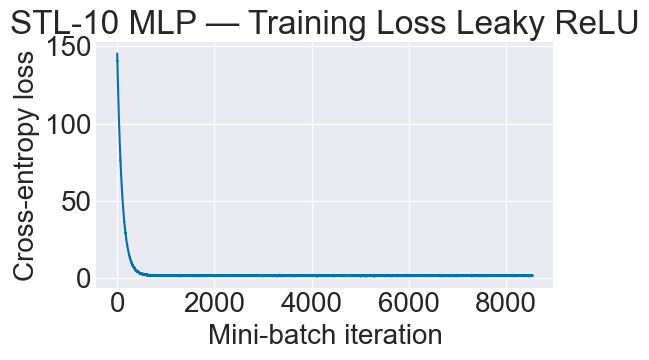

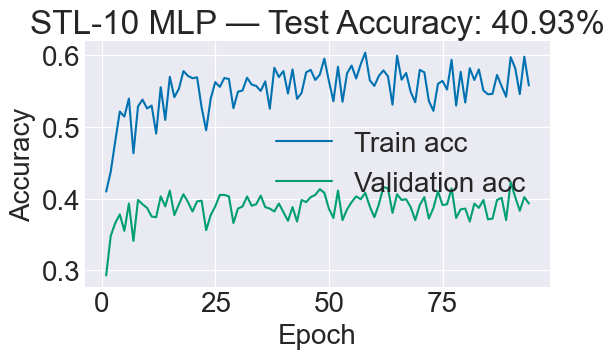

In [9]:
from mlp import MLP
from leakyReLUextension import leakyReLUextension
from multiHiddenMLP import multiHiddenMLP

num_features = x_train.shape[1]
num_classes = int(np.max(y_train)) + 1

net1 = leakyReLUextension(num_features, 101, num_classes)
loss_hist, acc_train, acc_valid = net1.fit(
    x_train, y_train,
    x_val, y_val,
    n_epochs=94,
    lr=0.05285802489413713,
    mini_batch_sz=33,
    reg=0.09008908547493312,
    r_seed=0,
    verbose=0
)
y_pred = net1.predict(x_test)
test_acc = np.mean(y_pred == y_test)

plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.xlabel("Mini-batch iteration")
plt.ylabel("Cross-entropy loss")
plt.title("STL-10 MLP — Training Loss Leaky ReLU")
plt.tight_layout()
plt.show()

epochs = np.arange(1, len(acc_train)+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, acc_train, label="Train acc")
plt.plot(epochs, acc_valid, label="Validation acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"STL-10 MLP — Test Accuracy: {test_acc * 100:.2f}%")
plt.legend()
plt.tight_layout()
plt.show()


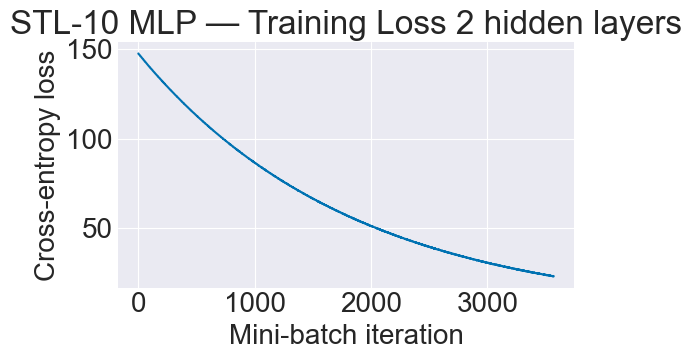

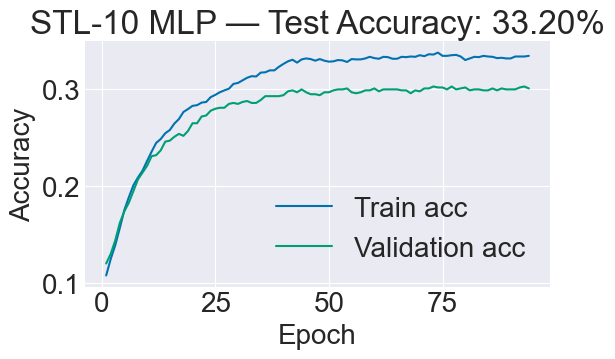

In [19]:
num_features = x_train.shape[1]
num_classes = int(np.max(y_train)) + 1

net2 = multiHiddenMLP(num_features, 101, 101, num_classes)
loss_hist, acc_train, acc_valid = net2.fit(
    x_train, y_train,
    x_val, y_val,
    n_epochs=94,
    lr=0.003,
    mini_batch_sz=80,
    reg=0.09008908547493312,
    r_seed=0,
    verbose=0
)
y_pred = net2.predict(x_test)
test_acc = np.mean(y_pred == y_test)

plt.figure(figsize=(6,4))
plt.plot(loss_hist)
plt.xlabel("Mini-batch iteration")
plt.ylabel("Cross-entropy loss")
plt.title("STL-10 MLP — Training Loss 2 hidden layers")
plt.tight_layout()
plt.show()

epochs = np.arange(1, len(acc_train)+1)

plt.figure(figsize=(6,4))
plt.plot(epochs, acc_train, label="Train acc")
plt.plot(epochs, acc_valid, label="Validation acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"STL-10 MLP — Test Accuracy: {test_acc * 100:.2f}%")
plt.legend()
plt.tight_layout()
plt.show()